In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [2]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.xlsx - Sheet1.csv',sep=',',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.xlsx') #excel
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1588 entries, 0 to 1587
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1588 non-null   str  
 1   Message  1588 non-null   str  
 2   Status   1588 non-null   str  
dtypes: str(3)
memory usage: 37.3 KB


In [3]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('3E0')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [4]:
#I must deleted 3 last elements of the messahe because of an error that mix fuel sensor 1 with fuel sensor 2.
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
fs01_raw_data=[]
date_fs02_dec_value=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E01')
    if aux>123:
        if len(e0x_aux)>0:
            fs01=(e0x_aux[aux:aux+72])
            #print(fs01,aux)
            if len(fs01)>17:
                #print(e0x_aux,aux,fs01)
                msb=fs01[10:12]
                lsb=fs01[8:10]
                measure=msb+lsb
                fs01_dec_value.append(int(measure,16))
                date_fs01_dec_value.append(e0x.iloc[i,0])            
                fs01_raw_data.append(e0x.iloc[i,2])
            
#print(i, raw_fuel_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E02')
    if aux>123:
        if len(e0x_aux)>0:
            fs02=(e0x_aux[aux:aux+72])
            if len(fs02)>17:
                msb=fs02[10:12]
                lsb=fs02[8:10]
                measure=msb+lsb
                fs02_dec_value.append(int(measure,16))
                date_fs02_dec_value.append(e0x.iloc[i,0])
                fs02_raw_data.append(e0x.iloc[i,2])              

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)

print(fs01_count)
print('fs01_dec_value',len(fs01_dec_value),'date_fs01_dec_value',len(date_fs01_dec_value))
values_dates_fs01['Value fs01']=fs01_dec_value
values_dates_fs01['Dates fs01']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['Value fs02']=fs02_dec_value
values_dates_fs02['Dates fs02']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

print("Last fuel report fs01: ",e0x.iloc[fs01_count,0],"Last fuel report fs02: ",e0x.iloc[fs02_count,0])        


26
fs01_dec_value 26 date_fs01_dec_value 26
Last fuel report fs01:  2026-08-30 17:18:59.162 Last fuel report fs02:  2026-08-31 18:25:24.333


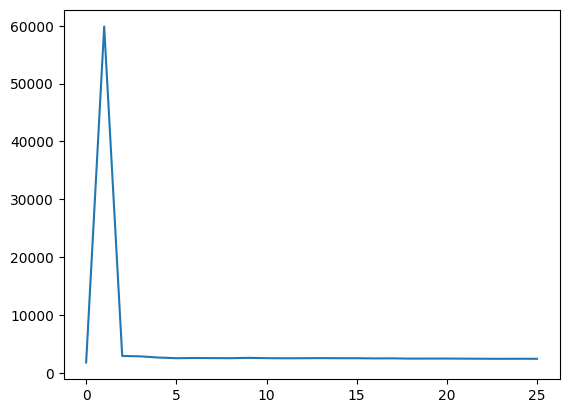

In [5]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,fs01_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

In [6]:
for i in range(0,values_dates_fs01.shape[0]):
    if int(values_dates_fs01.iloc[i,0])>4095:
        print(values_dates_fs01.iloc[i,2],values_dates_fs01.iloc[i,0])

0x8305476440081001010104000F6A9444A56A9444A5067D7F35D36F0243000003230000055900B90B020065FFB14F083700000500241E0738BC3CCFCB023E01C709E8E90CFECD373E01120725DA0C7B73D83EF11610F21CA873 59880


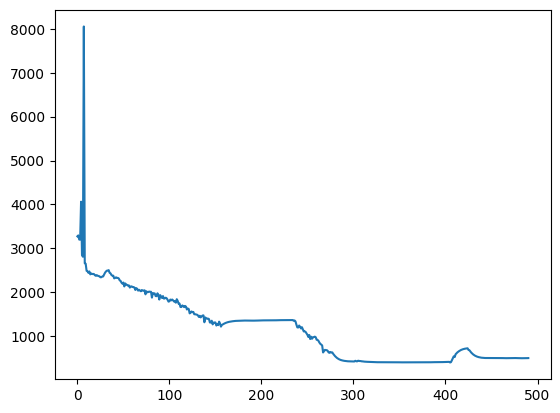

In [7]:
plt.plot(fs02_x_values,fs02_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

In [8]:
for i in range(0,values_dates_fs02.shape[0]):
    if int(values_dates_fs02.iloc[i,0])>4095:
        print(values_dates_fs02.iloc[i,2],values_dates_fs02.iloc[i,0])

0x8305476440081001010104008A6A9473D76A9473D705B6CB2ED32F0BD1000056B2000006A600D909200065FF8F4F09170000050024285FA869B42980A7653E020727761F6BA78D2FA13BB33E02072568FA8EBEF7FB29E1A771 8054
